In [1]:
from langgraph.graph import StateGraph, START , END 
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",  # Choose any model supporting Inference API
    task="text-generation",
    max_new_tokens=1024,
    do_sample=False,
    repetition_penalty=1.03,
    temperature=0.7,
)

# 2. Wrap with ChatHuggingFace
model = ChatHuggingFace(llm=llm, verbose=True)



d:\langgraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class BlogState(TypedDict):
    title: str
    outline:str
    blog_content:str
    eval_score:int
    

In [4]:
def create_outline (state:BlogState)->BlogState:
    title = state["title"]

    prompt = f"Wirte me a detailed outline for a blog on title {title}"

    outline = model.invoke(prompt)

    state["outline"] = outline.content

    return state

def create_blog (state:BlogState)->BlogState:
    title = state["title"]
    outline = state["outline"]

    prompt = f"Wirte me a detailed blog for a blog on title {title} following this outline \n {outline}"

    blog_content = model.invoke(prompt)

    state["blog_content"] = blog_content.content

    return state

def evaluate_blog(state:BlogState)->BlogState:
    title = state["title"]
    outline= state["outline"]
    blog_content = state["blog_content"]

    prompt = f"Based on my outline and content bellow evaluate my blog and return me just a single integer score on range 1-5 (5 means outline is fully followed and 1 means not followed). DO not return a single letter or symbol or anything else . Just a integer rating between 1-5.\n Outline:\n {outline} \n Content:\n {blog_content}"

    evaluation_score = model.invoke(prompt)
    state["eval_score"] = evaluation_score.content
    
    return state



In [5]:
#define graph 
graph = StateGraph(BlogState)

#define nodes 

graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)
graph.add_node("evaluate_blog",evaluate_blog)

#define edge connections 
graph.add_edge(START , "create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog","evaluate_blog")
graph.add_edge("evaluate_blog",END)

#compile graph
workflow = graph.compile()

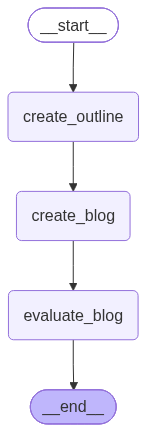

In [6]:
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
#execute the graph 
initial_state = {'title':'father of AI'}

final_state = workflow.invoke(initial_state)



In [8]:
print(final_state)

{'title': 'father of AI', 'outline': 'Here is a detailed outline for a blog on the "Father of AI":\n\n**Title:** The Father of AI: A Tribute to Alan Turing\n\n**I. Introduction**\n\n* Brief overview of the blog post and its topic\n* Importance of recognizing Alan Turing\'s contributions to the field of Artificial Intelligence (AI)\n* Thesis statement: Alan Turing, a British mathematician, computer scientist, and logician, is widely regarded as the father of AI due to his pioneering work in computer science, cryptography, and theoretical computer science.\n\n**II. Early Life and Education**\n\n* Brief biography of Alan Turing (1912-1954)\n* Description of his early interests in mathematics and science\n* Overview of his education at King\'s College, Cambridge, and his subsequent appointment as a fellow at the college\n\n**III. Contributions to AI**\n\n* Discussion of Turing\'s 1936 paper "On Computable Numbers, with an Application to the Decision Problem" (the Turing Machine)\n\t+ Expla

In [9]:
print(final_state["outline"])

Here is a detailed outline for a blog on the "Father of AI":

**Title:** The Father of AI: A Tribute to Alan Turing

**I. Introduction**

* Brief overview of the blog post and its topic
* Importance of recognizing Alan Turing's contributions to the field of Artificial Intelligence (AI)
* Thesis statement: Alan Turing, a British mathematician, computer scientist, and logician, is widely regarded as the father of AI due to his pioneering work in computer science, cryptography, and theoretical computer science.

**II. Early Life and Education**

* Brief biography of Alan Turing (1912-1954)
* Description of his early interests in mathematics and science
* Overview of his education at King's College, Cambridge, and his subsequent appointment as a fellow at the college

**III. Contributions to AI**

* Discussion of Turing's 1936 paper "On Computable Numbers, with an Application to the Decision Problem" (the Turing Machine)
	+ Explanation of the Turing Machine and its significance in the deve

In [10]:
print(final_state["blog_content"])

**The Father of AI: A Tribute to Alan Turing**

Alan Turing, a British mathematician, computer scientist, and logician, is widely regarded as the father of Artificial Intelligence (AI). His pioneering work in computer science, cryptography, and theoretical computer science has had a profound impact on the development of modern computers and the field of AI. In this blog post, we will delve into Turing's early life and education, his contributions to AI, his work on the Turing Test, cryptography and codebreaking, and his lasting legacy.

**Early Life and Education**

Alan Mathison Turing was born on June 23, 1912, in Maida Vale, London. He was the second of two children to a British Army officer, and his family's military background would later influence his work in cryptography and codebreaking. Turing's early interests in mathematics and science were encouraged by his family, and he was accepted into King's College, Cambridge, at the age of 19. During his time at Cambridge, Turing bec